# General

For more informations, si the documentation *Documentary Strategy*.

# Import & Configs

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Data Upload

In [2]:
def  get_documents_df():
    documents = []
    
    with open("../data/raw/pubmed_abstracts.jsonl", "r") as f:
        for line in f:
            documents.append(json.loads(line))

    df = pd.DataFrame(documents)
    return df

In [3]:
df = get_documents_df()
df.head()

,pmid,raw_text
0,42200192,\nPMID- 42200192\nOWN - NLM\nSTAT- PubMed-not-...
1,42200191,\nPMID- 42200191\nOWN - NLM\nSTAT- PubMed-not-...
2,42198443,\nPMID- 42198443\nOWN - NLM\nSTAT- PubMed-not-...
3,42198270,\nPMID- 42198270\nOWN - NLM\nSTAT- PubMed-not-...
4,42195335,\nPMID- 42195335\nOWN - NLM\nSTAT- PubMed-not-...


In [4]:
len(df)

500

All documents are loaded.

In [5]:
print(df.iloc[0]["raw_text"][:3000])


PMID- 42200192
OWN - NLM
STAT- PubMed-not-MEDLINE
DCOM- 20260527
LR  - 20260527
IS  - 2632-2498 (Electronic)
IS  - 2632-2498 (Linking)
VI  - 8
IP  - 1
DP  - 2026 Jan-Dec
TI  - Prediction of treatment failure in patients with glioblastoma with perfusion MRI 
      and molecular biomarkers.
PG  - vdag119
LID - 10.1093/noajnl/vdag119 [doi]
AB  - BACKGROUND: Predicting early treatment failure in glioblastoma remains 
      challenging. Given the median survival of 13.5 months, better prognostic 
      biomarkers are needed. This study aimed to identify predictors of early treatment 
      failure and their association with overall survival (OS). METHODS: We performed a 
      retrospective analysis of consecutive patients with newly diagnosed glioblastoma 
      who underwent DSC- and DCE-MRI before surgery and radiochemotherapy. Treatment 
      failure was defined as tumor progression per RANO 2.0 criteria within 6 months of 
      surgery. Factors independently associated with outcome 

-> [Original article page](https://pubmed.ncbi.nlm.nih.gov/42200192/)

-> We have access to some metadata, such as in the bibliography. Because we truncate the printed text, some authors and DOIs are missing.

# Missings

## Missings Abstract

In [6]:
df["has_abstract"] = df["raw_text"].str.contains("AB  -")

df["has_abstract"].value_counts()

has_abstract
True     477
False     23
Name: count, dtype: int64

In [7]:
df["has_abstract"].value_counts(normalize=True)*100

has_abstract
True     95.4
False     4.6
Name: proportion, dtype: float64

## Removing missings abstract

In [8]:
df = df[df["has_abstract"]].copy()

In [9]:
len(df)

477

## Missings Titles

In [10]:
df["has_title"] = df["raw_text"].str.contains("TI  -")

df["has_title"].value_counts()

has_title
True     476
False      1
Name: count, dtype: int64

## Removing missings titles

In [11]:
df = df[df["has_title"]].copy()

In [12]:
len(df)

476

## Missings Data

In [13]:
df["has_date"] = df["raw_text"].str.contains("DP  -")

df["has_date"].value_counts()

has_date
True    476
Name: count, dtype: int64

## Other missings
Some other metadata may be missing. Since we haven't defined a strategy for metadata, we will not investigate it for now, but we can do so later.

# Abstract sizes

In [14]:
df["text_length"] = df["raw_text"].apply(len)

In [15]:
df["text_length"].describe()

count      476.000000
mean      5286.964286
std       1900.835556
min       1923.000000
25%       4051.250000
50%       4886.500000
75%       6127.250000
max      15641.000000
Name: text_length, dtype: float64

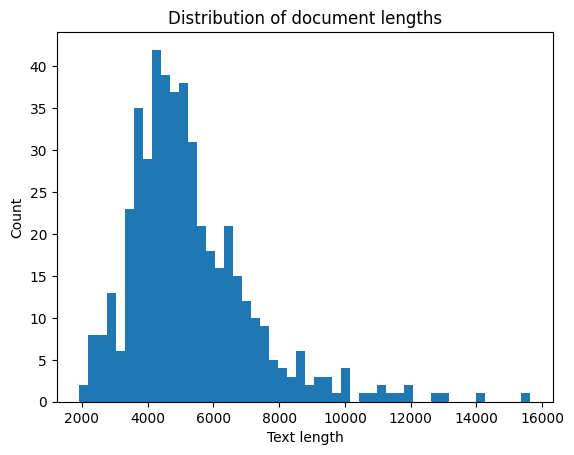

In [16]:
plt.hist(df["text_length"], bins=50)
plt.xlabel("Text length")
plt.ylabel("Count")
plt.title("Distribution of document lengths")
plt.show()

<Axes: ylabel='text_length'>

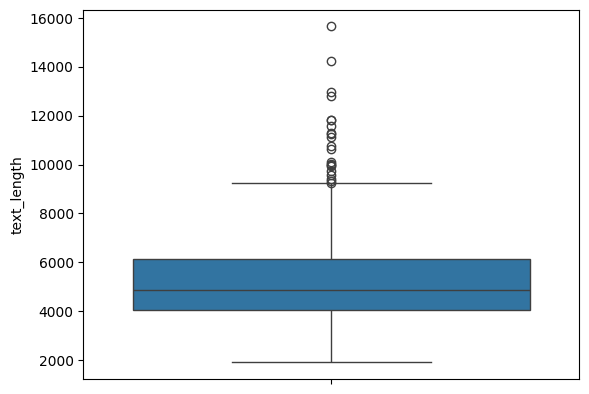

In [17]:
sns.boxplot(data=df["text_length"])

There are some outliers after 9,000 characters. There are no small outliers. The abstracts mainly center around 5,000 characters, forming a Gaussian curve that is slightly more spread out on the right.

# Structured Parsing

In [26]:
df = get_documents_df()
df.head()

,pmid,raw_text
0,42200192,\nPMID- 42200192\nOWN - NLM\nSTAT- PubMed-not-...
1,42200191,\nPMID- 42200191\nOWN - NLM\nSTAT- PubMed-not-...
2,42198443,\nPMID- 42198443\nOWN - NLM\nSTAT- PubMed-not-...
3,42198270,\nPMID- 42198270\nOWN - NLM\nSTAT- PubMed-not-...
4,42195335,\nPMID- 42195335\nOWN - NLM\nSTAT- PubMed-not-...


In [27]:
def extract_pmid(text):

    match = re.search(r"PMID\s*-\s*(\d+)", text)

    if match:
        return match.group(1)

    return None

def extract_title(text):

    match = re.search(r"TI\s*-\s*(.+)", text)

    if match:
        return match.group(1).strip()

    return None

def extract_abstract(text):

    match = re.search(
        r"AB\s*-\s*(.*?)(?:\n[A-Z]{2,4}\s*-|\Z)",
        text,
        re.DOTALL
    )

    if match:
        abstract = match.group(1).strip()

        abstract = re.sub(r"\s+", " ", abstract)

        return abstract

    return None

def extract_year(text):

    match = re.search(r"DP\s*-\s*(\d{4})", text)

    if match:
        return match.group(1)

    return None


In [28]:
df["pmid"] = df["raw_text"].apply(extract_pmid)

df["title"] = df["raw_text"].apply(extract_title)

df["abstract"] = df["raw_text"].apply(extract_abstract)

df["year"] = df["raw_text"].apply(extract_year)

In [29]:
df[["pmid", "title", "year"]].head()

,pmid,title,year
0,42200192,Prediction of treatment failure in patients wi...,2026
1,42200191,Imaging patterns of glioblastoma progression: ...,2026
2,42198443,Antitumor Activity of Cannabinoids and Their I...,2026
3,42198270,Ultrasound-Enhanced Drug Delivery in Pediatric...,2026
4,42195335,Artificial Intelligence-Based MRI Segmentation...,2026


In [30]:
print(df.iloc[0]["abstract"])

BACKGROUND: Predicting early treatment failure in glioblastoma remains challenging. Given the median survival of 13.5 months, better prognostic biomarkers are needed. This study aimed to identify predictors of early treatment failure and their association with overall survival (OS). METHODS: We performed a retrospective analysis of consecutive patients with newly diagnosed glioblastoma who underwent DSC- and DCE-MRI before surgery and radiochemotherapy. Treatment failure was defined as tumor progression per RANO 2.0 criteria within 6 months of surgery. Factors independently associated with outcome among clinical, MRI perfusion at the diagnosis and molecular parameters were identified using multivariable logistic regression models. OS was evaluated using a 180-day landmark analysis to avoid time-dependent bias. RESULTS: Among 62 patients diagnosed between 01/2017 and 12/2021, 44 patients (71%) were non-responders and 18 patients (29%) responders. Elevated pretreatment rCBV and Ktrans we

## Data Cleaning

In [31]:
df[["pmid", "title", "abstract", "year"]].isna().sum()

pmid         0
title        0
abstract    22
year         0
dtype: int64

In [ ]:
df = df.dropna(subset=["pmid", "title", "abstract", "year"])

# Drop duplicates

In [22]:
df = df.drop_duplicates(subset=["pmid"])

In [23]:
len(df)

476

# Merge *title* and *abstract* in *text*
Better for the chunking step.

In [ ]:
df["text"] = (
    df["title"] + ". " + df["abstract"]
)

In [ ]:
df[["title", "abstract", "text"]].head()

# Download cleaned data

In [24]:
output_path = "../data/processed/clean_documents.jsonl"

In [25]:
with open(output_path, "w") as f:

    for _, row in df.iterrows():

        record = {
            "pmid": row["pmid"],
            "title": row["title"],
            "abstract": row["abstract"],
            "year": row["year"],
            "text": row["text"]
        }

        f.write(json.dumps(record) + "\n")